In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum


spark=SparkSession.builder.appName("practice").getOrCreate()

In [2]:
data = [
    ["001","101","John Doe","30","Male","50000","2015-01-01"],
    ["002","101","Jane Smith","25","Female","45000","2016-02-15"],
    ["003","102","Bob Brown","35","Male","55000","2014-05-01"],
    ["004","102","Alice Lee","28","Female","48000","2017-09-30"],
    ["005","103","Jack Chan","40","Male","60000","2013-04-01"],
    ["006","103","Jill Wong","32","Female","52000","2018-07-01"],
    ["007","101","James Johnson","42","Male","70000","2012-03-15"],
    ["008","102","Kate Kim","29","Female","51000","2019-10-01"],
    ["009","103","Tom Tan","33","Male","58000","2016-06-01"],
    ["010","104","Lisa Lee","27","Female","47000","2018-08-01"],
    ["011","104","David Park","38","Male","65000","2015-11-01"],
    ["012","105","Susan Chen","31","Female","54000","2017-02-15"],
    ["013","106","Brian Kim","45","Male","75000","2011-07-01"],
    ["014","107","Emily Lee","26","Female","46000","2019-01-01"],
    ["015","106","Michael Lee","37","Male","63000","2014-09-30"],
    ["016","107","Kelly Zhang","30","Female","49000","2018-04-01"],
    ["017","105","George Wang","34","Male","57000","2016-03-15"],
    ["018","104","Nancy Liu","29","Female","50000","2017-06-01"],
    ["019","103","Steven Chen","36","Male","62000","2015-08-01"],
    ["020","102","Grace Kim","32","Female","53000","2018-11-01"]
]

schema = "employee_id string, department_id string, name string, age string, gender string, salary string, hire_date string"

In [3]:
df=spark.createDataFrame(data=data,schema=schema)

In [4]:
df.show()

+-----------+-------------+-------------+---+------+------+----------+
|employee_id|department_id|         name|age|gender|salary| hire_date|
+-----------+-------------+-------------+---+------+------+----------+
|        001|          101|     John Doe| 30|  Male| 50000|2015-01-01|
|        002|          101|   Jane Smith| 25|Female| 45000|2016-02-15|
|        003|          102|    Bob Brown| 35|  Male| 55000|2014-05-01|
|        004|          102|    Alice Lee| 28|Female| 48000|2017-09-30|
|        005|          103|    Jack Chan| 40|  Male| 60000|2013-04-01|
|        006|          103|    Jill Wong| 32|Female| 52000|2018-07-01|
|        007|          101|James Johnson| 42|  Male| 70000|2012-03-15|
|        008|          102|     Kate Kim| 29|Female| 51000|2019-10-01|
|        009|          103|      Tom Tan| 33|  Male| 58000|2016-06-01|
|        010|          104|     Lisa Lee| 27|Female| 47000|2018-08-01|
|        011|          104|   David Park| 38|  Male| 65000|2015-11-01|
|     

In [5]:
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+-----------+-------------+----+---+------+------+---------+
|employee_id|department_id|name|age|gender|salary|hire_date|
+-----------+-------------+----+---+------+------+---------+
|          0|            0|   0|  0|     0|     0|        0|
+-----------+-------------+----+---+------+------+---------+



In [6]:
df.printSchema()

root
 |-- employee_id: string (nullable = true)
 |-- department_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- age: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- salary: string (nullable = true)
 |-- hire_date: string (nullable = true)



In [7]:
num_rows = df.count()
num_cols = len(df.columns)
print(f"Shape: ({num_rows}, {num_cols})")

Shape: (20, 7)


In [8]:
df=df.drop("employee_id","department_id")

In [9]:
df.show()

+-------------+---+------+------+----------+
|         name|age|gender|salary| hire_date|
+-------------+---+------+------+----------+
|     John Doe| 30|  Male| 50000|2015-01-01|
|   Jane Smith| 25|Female| 45000|2016-02-15|
|    Bob Brown| 35|  Male| 55000|2014-05-01|
|    Alice Lee| 28|Female| 48000|2017-09-30|
|    Jack Chan| 40|  Male| 60000|2013-04-01|
|    Jill Wong| 32|Female| 52000|2018-07-01|
|James Johnson| 42|  Male| 70000|2012-03-15|
|     Kate Kim| 29|Female| 51000|2019-10-01|
|      Tom Tan| 33|  Male| 58000|2016-06-01|
|     Lisa Lee| 27|Female| 47000|2018-08-01|
|   David Park| 38|  Male| 65000|2015-11-01|
|   Susan Chen| 31|Female| 54000|2017-02-15|
|    Brian Kim| 45|  Male| 75000|2011-07-01|
|    Emily Lee| 26|Female| 46000|2019-01-01|
|  Michael Lee| 37|  Male| 63000|2014-09-30|
|  Kelly Zhang| 30|Female| 49000|2018-04-01|
|  George Wang| 34|  Male| 57000|2016-03-15|
|    Nancy Liu| 29|Female| 50000|2017-06-01|
|  Steven Chen| 36|  Male| 62000|2015-08-01|
|    Grace

In [10]:
from pyspark.sql.functions import year, month, dayofmonth, col
df=df.withColumn("hire_date",col("hire_date").cast("date"))

df=df.withColumn("year",year(col("hire_date")))
df=df.withColumn("month",month(col("hire_date")))
df=df.withColumn("day",dayofmonth(col("hire_date")))

In [11]:
df=df.drop("hire_date")

In [12]:
from pyspark.ml.feature import StringIndexer
name_index=StringIndexer(inputCol="name",outputCol="name_index")
df=name_index.fit(df).transform(df)

In [13]:
name_index=StringIndexer(inputCol="gender",outputCol="gender_index")
df=name_index.fit(df).transform(df)

In [14]:
df=df.drop("name","gender")

In [15]:
df.show()

+---+------+----+-----+---+----------+------------+
|age|salary|year|month|day|name_index|gender_index|
+---+------+----+-----+---+----------+------------+
| 30| 50000|2015|    1|  1|      11.0|         1.0|
| 25| 45000|2016|    2| 15|       9.0|         0.0|
| 35| 55000|2014|    5|  1|       1.0|         1.0|
| 28| 48000|2017|    9| 30|       0.0|         0.0|
| 40| 60000|2013|    4|  1|       7.0|         1.0|
| 32| 52000|2018|    7|  1|      10.0|         0.0|
| 42| 70000|2012|    3| 15|       8.0|         1.0|
| 29| 51000|2019|   10|  1|      12.0|         0.0|
| 33| 58000|2016|    6|  1|      19.0|         1.0|
| 27| 47000|2018|    8|  1|      14.0|         0.0|
| 38| 65000|2015|   11|  1|       3.0|         1.0|
| 31| 54000|2017|    2| 15|      18.0|         0.0|
| 45| 75000|2011|    7|  1|       2.0|         1.0|
| 26| 46000|2019|    1|  1|       4.0|         0.0|
| 37| 63000|2014|    9| 30|      15.0|         1.0|
| 30| 49000|2018|    4|  1|      13.0|         0.0|
| 34| 57000|

In [16]:
df = df.withColumn("age", col("age").cast("int"))


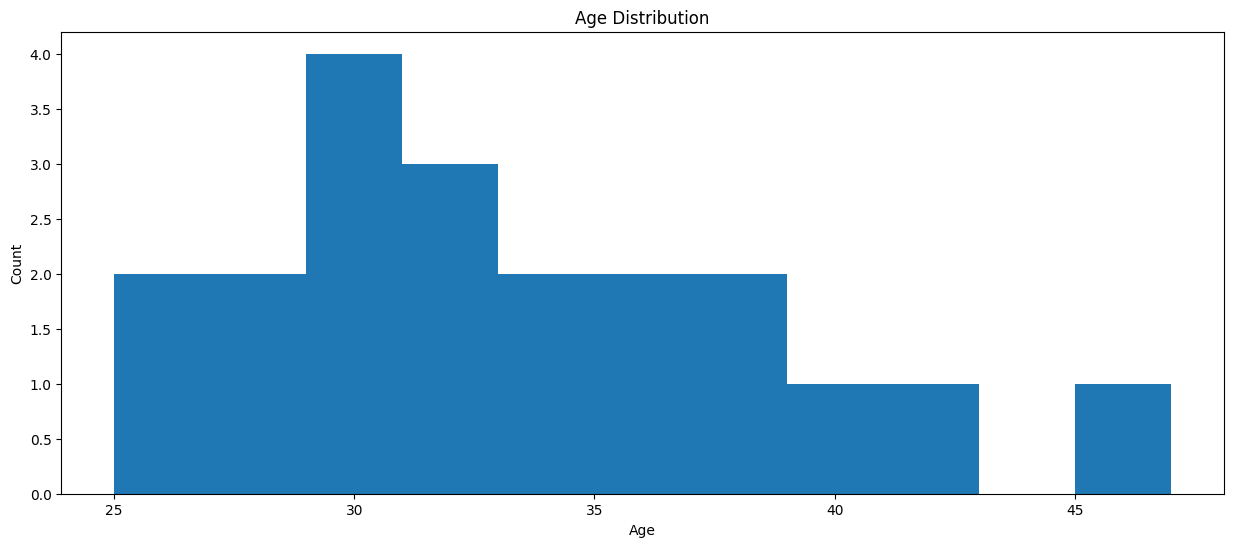

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, floor

bins = 10
age_min = df.select("age").rdd.min()[0]
age_max = df.select("age").rdd.max()[0]
bin_width = (age_max - age_min) / bins

# Create bins
df_age_bins = df.select(floor((col("age") - age_min) / bin_width).alias("bin")).groupBy("bin").count()

# Collect data for plotting
age_hist = df_age_bins.collect()
bins = [row["bin"] * bin_width + age_min for row in age_hist]
counts = [row["count"] for row in age_hist]

# Plot
plt.figure(figsize=(15, 6))
plt.bar(bins, counts, width=bin_width, align="edge")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

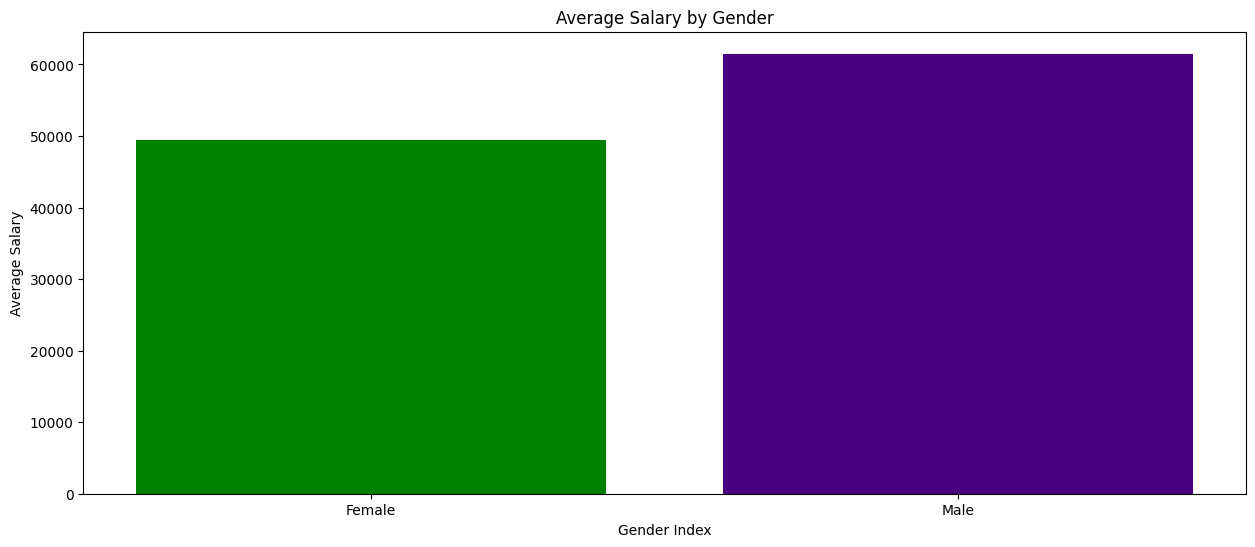

In [18]:
from pyspark.sql.functions import avg

df_gender_salary = df.groupBy("gender_index").agg(avg("salary").alias("avg_salary")).orderBy("gender_index")
gender_salary = df_gender_salary.collect()
genders = [row["gender_index"] for row in gender_salary]
avg_salaries = [row["avg_salary"] for row in gender_salary]

# Plot
plt.figure(figsize=(15, 6))
plt.bar(genders, avg_salaries,color=["green","indigo"])
plt.xlabel("Gender Index")
plt.ylabel("Average Salary")
plt.title("Average Salary by Gender")
plt.xticks(genders, ["Female", "Male"])
plt.show()

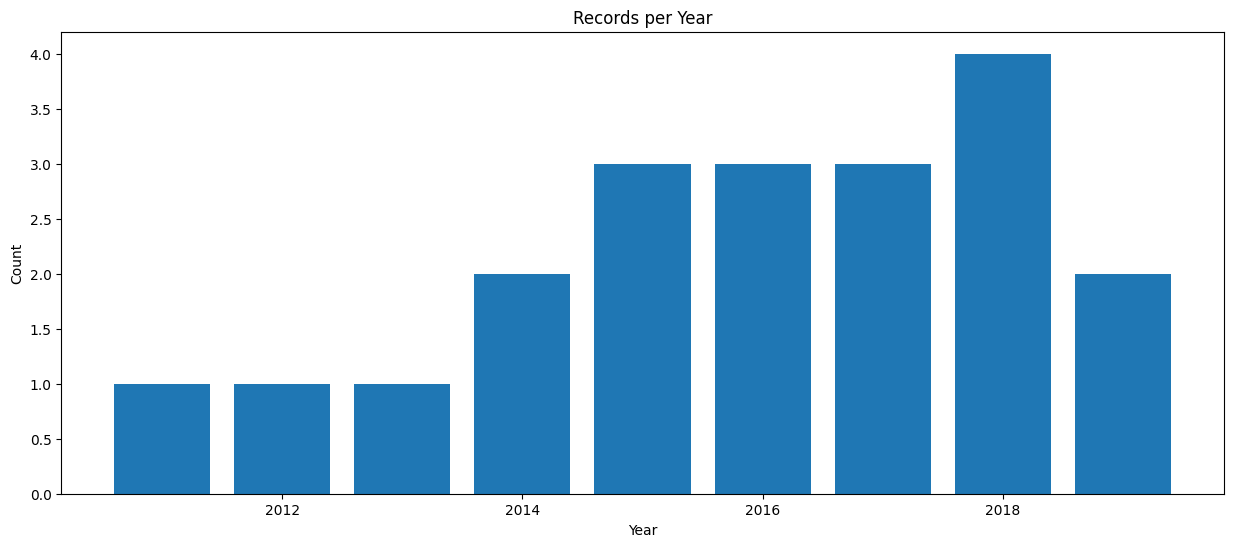

In [19]:
plt.figure(figsize=(15, 6))
df_year_count = df.groupBy("year").count().orderBy("year")
years = [row["year"] for row in df_year_count.collect()]
counts = [row["count"] for row in df_year_count.collect()]
plt.bar(years, counts)
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Records per Year")
plt.show()

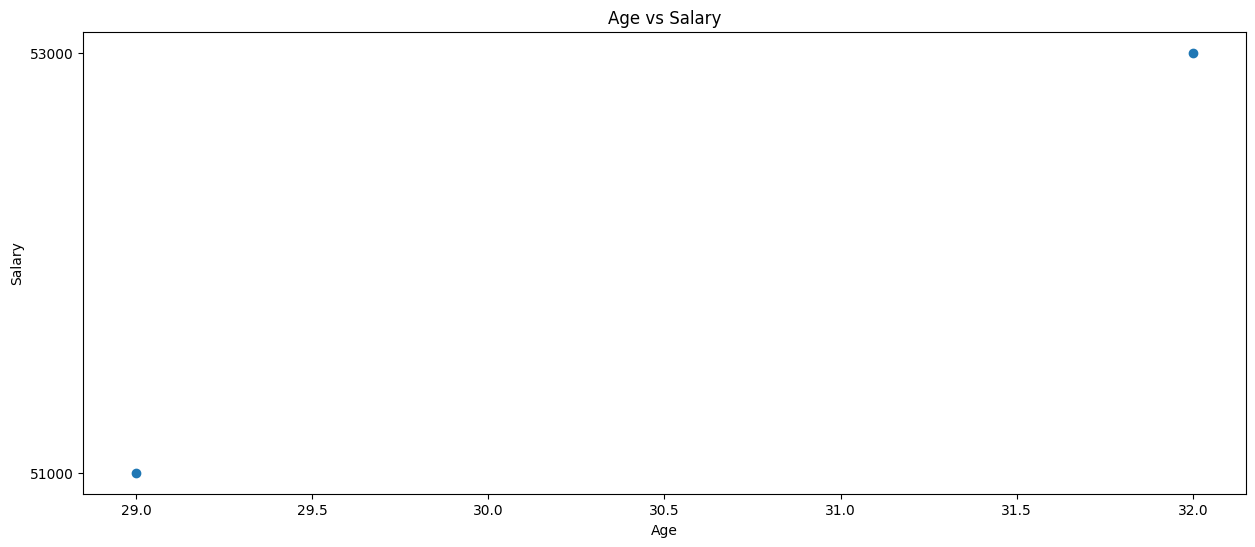

In [20]:
plt.figure(figsize=(15,6))
df_sample = df.select("age", "salary").sample(fraction=0.1, seed=42).collect()
ages = [row["age"] for row in df_sample]
salaries = [row["salary"] for row in df_sample]

# Plot
plt.scatter(ages, salaries)
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

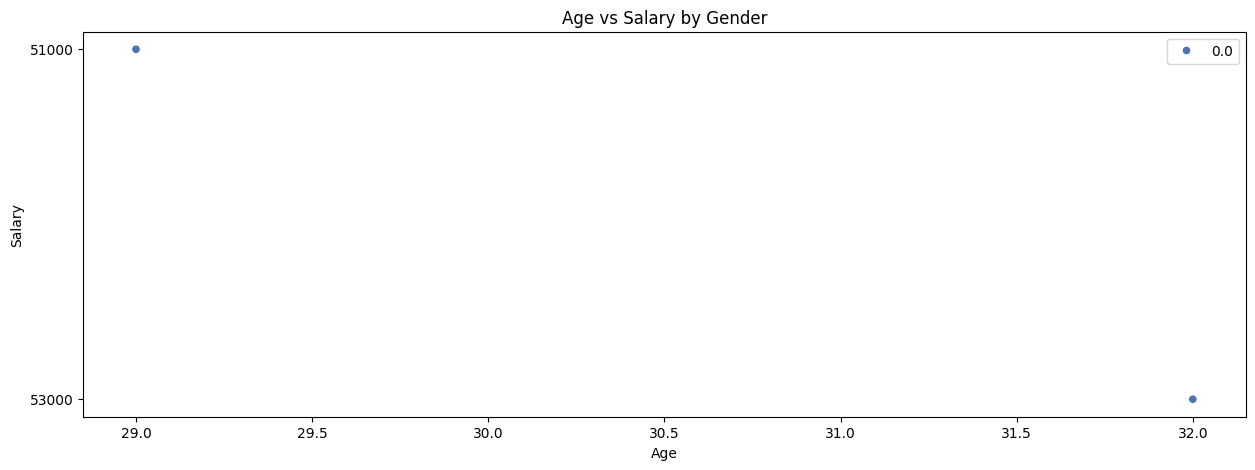

In [21]:
plt.figure(figsize=(15,5))
df_sample = df.select("age", "salary", "gender_index").sample(fraction=0.1, seed=42).collect()
ages = [row["age"] for row in df_sample]
salaries = [row["salary"] for row in df_sample]
genders = [row["gender_index"] for row in df_sample]
sns.scatterplot(x=ages, y=salaries, hue=genders, palette="deep")

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary by Gender")
plt.show()

/tmp/ipython-input-2269587037.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_salaries, male_salaries], labels=["Female", "Male"])


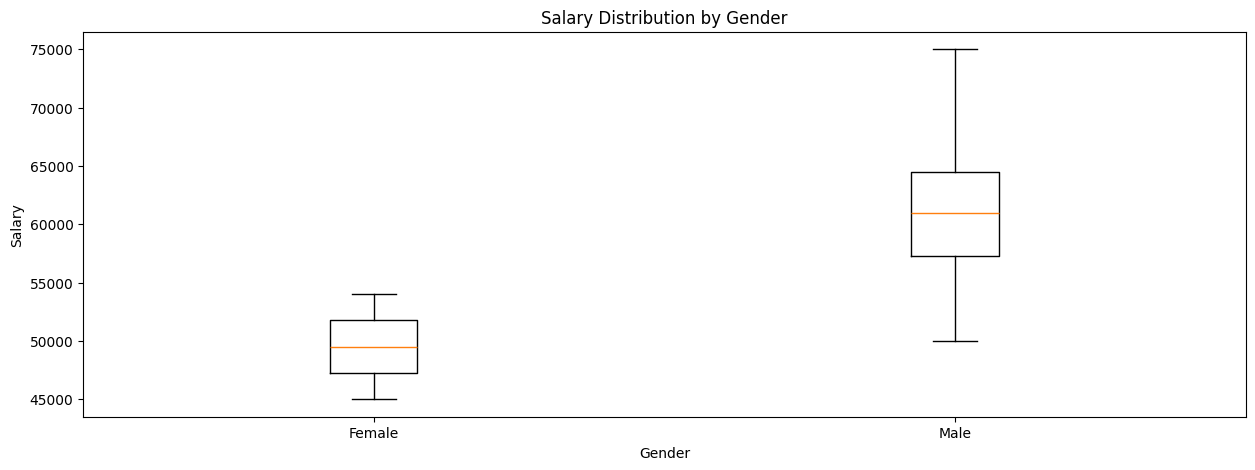

In [22]:
from pyspark.sql.functions import col
plt.figure(figsize=(15,5))
# Cast salary to float
df = df.withColumn("salary", col("salary").cast("float"))

# Collect salaries
female_salaries = df.filter(col("gender_index") == 0.0).select("salary").rdd.flatMap(lambda x: x).collect()
male_salaries = df.filter(col("gender_index") == 1.0).select("salary").rdd.flatMap(lambda x: x).collect()


plt.boxplot([female_salaries, male_salaries], labels=["Female", "Male"])
plt.xlabel("Gender")
plt.ylabel("Salary")
plt.title("Salary Distribution by Gender")
plt.show()


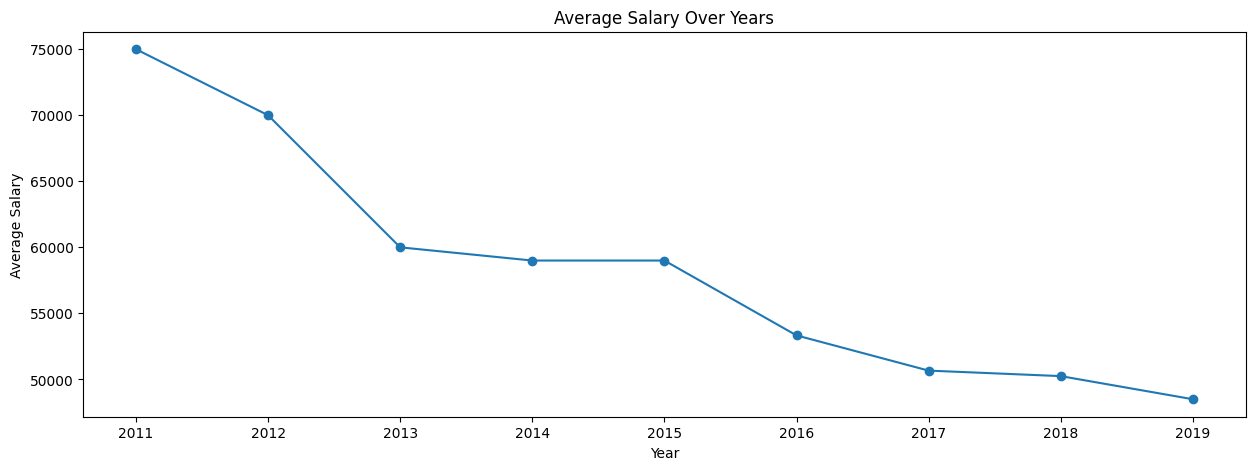

In [23]:
plt.figure(figsize=(15,5))
df_year_salary = df.groupBy("year").agg(avg("salary").alias("avg_salary")).orderBy("year")
year_salary = df_year_salary.collect()
years = [row["year"] for row in year_salary]
avg_salaries = [row["avg_salary"] for row in year_salary]

# Plot
plt.plot(years, avg_salaries, marker="o")
plt.xlabel("Year")
plt.ylabel("Average Salary")
plt.title("Average Salary Over Years")
plt.show()

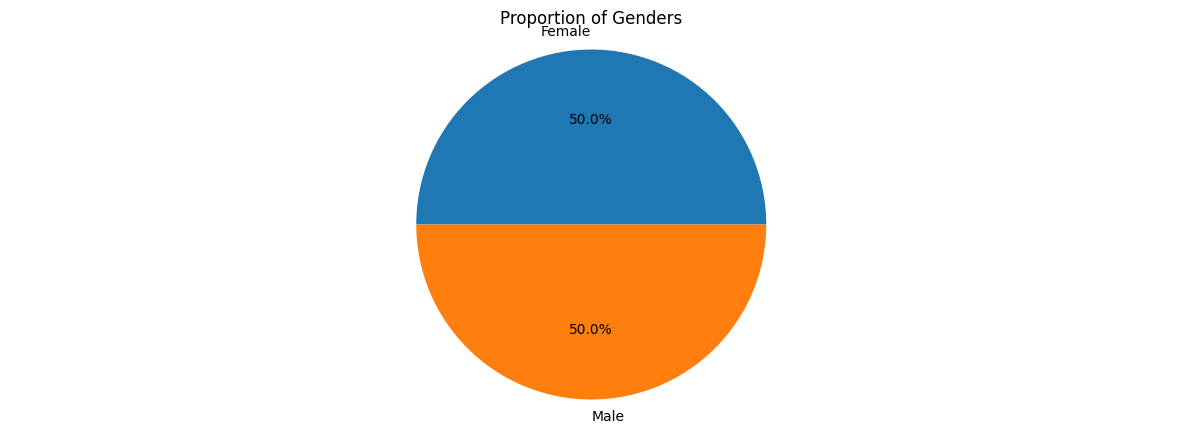

In [24]:
plt.figure(figsize=(15,5))
df_gender_count = df.groupBy("gender_index").count().collect()
labels = ["Female", "Male"]
sizes = [row["count"] for row in df_gender_count]
plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.title("Proportion of Genders")
plt.axis("equal")
plt.show()

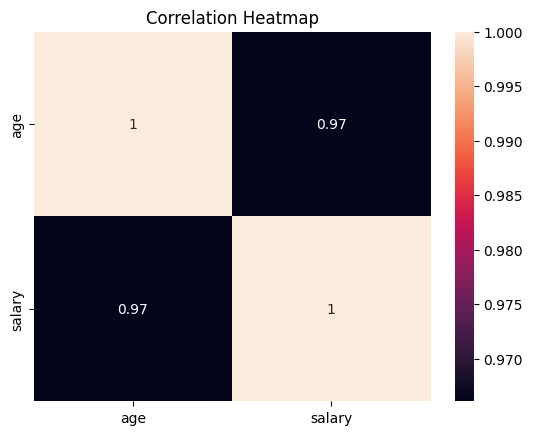

In [25]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import seaborn as sns
import numpy as np

# Create a vector column for correlation
assembler = VectorAssembler(inputCols=["age", "salary"], outputCol="features")
df_vector = assembler.transform(df)
corr_matrix = Correlation.corr(df_vector, "features").head()[0].toArray()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, xticklabels=["age", "salary"], yticklabels=["age", "salary"])
plt.title("Correlation Heatmap")
plt.show()

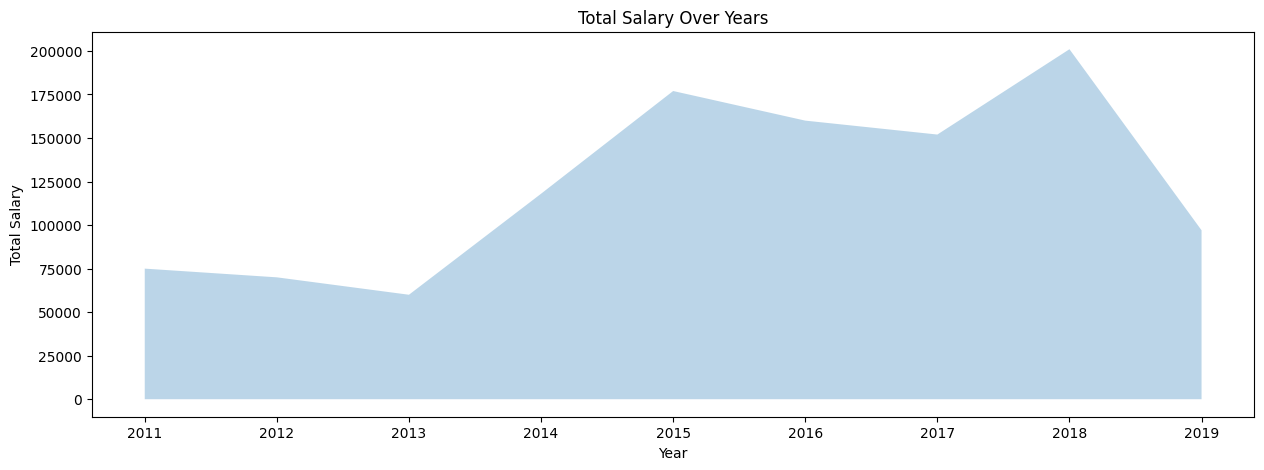

In [26]:
plt.figure(figsize=(15,5))
df_year_salary = df.groupBy("year").agg(sum("salary").alias("total_salary")).orderBy("year")
year_salary = df_year_salary.collect()
years = [row["year"] for row in year_salary]
total_salaries = [row["total_salary"] for row in year_salary]

# Plot
plt.fill_between(years, total_salaries, alpha=0.3)
plt.xlabel("Year")
plt.ylabel("Total Salary")
plt.title("Total Salary Over Years")
plt.show()

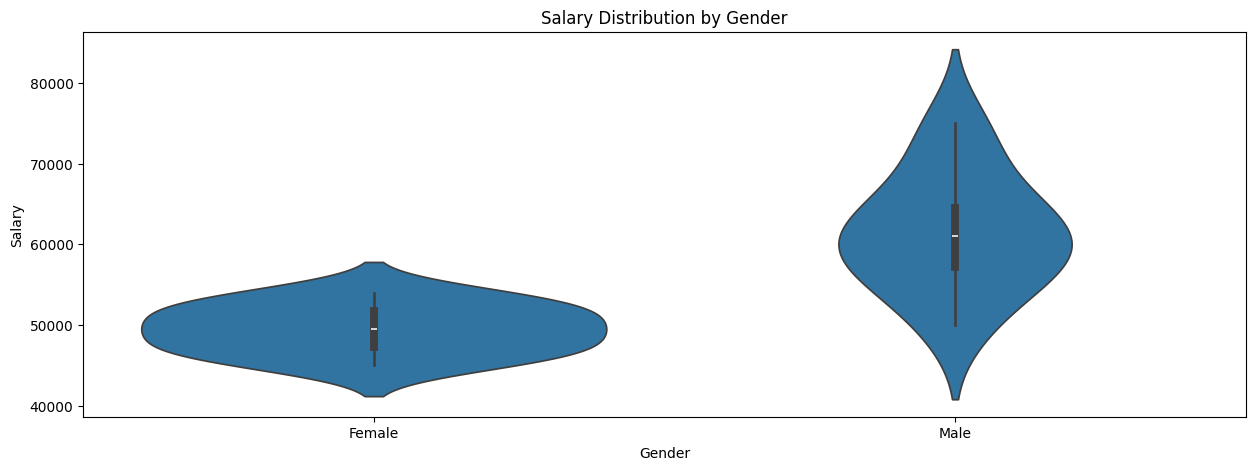

In [27]:
plt.figure(figsize=(15,5))
df_sample = df.select("gender_index", "salary").collect()
df_pandas = spark.createDataFrame(df_sample).toPandas()  # Minimal conversion
sns.violinplot(x="gender_index", y="salary", data=df_pandas)
plt.xlabel("Gender")
plt.ylabel("Salary")
plt.title("Salary Distribution by Gender")
plt.xticks([0, 1], ["Female", "Male"])
plt.show()

In [28]:
df.show()

+---+-------+----+-----+---+----------+------------+
|age| salary|year|month|day|name_index|gender_index|
+---+-------+----+-----+---+----------+------------+
| 30|50000.0|2015|    1|  1|      11.0|         1.0|
| 25|45000.0|2016|    2| 15|       9.0|         0.0|
| 35|55000.0|2014|    5|  1|       1.0|         1.0|
| 28|48000.0|2017|    9| 30|       0.0|         0.0|
| 40|60000.0|2013|    4|  1|       7.0|         1.0|
| 32|52000.0|2018|    7|  1|      10.0|         0.0|
| 42|70000.0|2012|    3| 15|       8.0|         1.0|
| 29|51000.0|2019|   10|  1|      12.0|         0.0|
| 33|58000.0|2016|    6|  1|      19.0|         1.0|
| 27|47000.0|2018|    8|  1|      14.0|         0.0|
| 38|65000.0|2015|   11|  1|       3.0|         1.0|
| 31|54000.0|2017|    2| 15|      18.0|         0.0|
| 45|75000.0|2011|    7|  1|       2.0|         1.0|
| 26|46000.0|2019|    1|  1|       4.0|         0.0|
| 37|63000.0|2014|    9| 30|      15.0|         1.0|
| 30|49000.0|2018|    4|  1|      13.0|       

In [29]:
feature_cols = [c for c in df.columns if c != "salary"]

In [30]:
from pyspark.ml.feature import VectorAssembler
from xgboost.spark import SparkXGBRegressor
from pyspark.sql import SparkSession
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from xgboost.spark import SparkXGBRegressor
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, VectorIndexer

In [31]:
train_df, test_df = df.randomSplit([0.7, 0.3], seed=42)

In [32]:
feature_cols=df.columns
feature_cols.remove("salary")
vector_assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
# vector_indexer = VectorIndexer(inputCol="features", outputCol="indexed_features", maxCategories=6)

In [33]:
xgb=SparkXGBRegressor(features_col="features", label_col="salary",prediction_col="prediction",num_workers=2)

In [34]:
paramgrid=ParamGridBuilder().addGrid(xgb.max_depth,[3,5,7]).addGrid(xgb.n_estimators,[100,200,300]).build()

In [35]:
evaluator=RegressionEvaluator(predictionCol="prediction",labelCol="salary",metricName="rmse")

In [36]:
cv = CrossValidator(estimator=xgb,estimatorParamMaps=paramgrid,evaluator=evaluator,numFolds=3)
pipeline = Pipeline(stages=[vector_assembler, cv])
pipelineModel = pipeline.fit(train_df)


INFO:XGBoost-PySpark:Running xgboost-3.0.4 on 2 workers with
	booster params: {'device': 'cpu', 'max_depth': 3, 'objective': 'reg:squarederror', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!
INFO:XGBoost-PySpark:Running xgboost-3.0.4 on 2 workers with
	booster params: {'device': 'cpu', 'max_depth': 3, 'objective': 'reg:squarederror', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 200}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!
INFO:XGBoost-PySpark:Running xgboost-3.0.4 on 2 workers with
	booster params: {'device': 'cpu', 'max_depth': 3, 'objective': 'reg:squarederror', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 300}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!
INFO:XGBoost-

In [37]:
predictions = pipelineModel.transform(test_df)
predictions.select("salary", "prediction", *feature_cols).show(10, truncate=False)


+-------+--------------+---+----+-----+---+----------+------------+
|salary |prediction    |age|year|month|day|name_index|gender_index|
+-------+--------------+---+----+-----+---+----------+------------+
|48000.0|47283.26953125|28 |2017|9    |30 |0.0       |0.0         |
|58000.0|53683.83984375|33 |2016|6    |1  |19.0      |1.0         |
|60000.0|64999.99609375|40 |2013|4    |1  |7.0       |1.0         |
|70000.0|64999.99609375|42 |2012|3    |15 |8.0       |1.0         |
|46000.0|45850.484375  |26 |2019|1    |1  |4.0       |0.0         |
|57000.0|54555.71484375|34 |2016|3    |15 |5.0       |1.0         |
|62000.0|54137.70703125|36 |2015|8    |1  |17.0      |1.0         |
|63000.0|54795.58984375|37 |2014|9    |30 |15.0      |1.0         |
+-------+--------------+---+----+-----+---+----------+------------+



In [38]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col, pow, mean, abs as F_abs

# RMSE
evaluator_rmse = RegressionEvaluator(labelCol="salary", predictionCol="prediction", metricName="rmse")
rmse = evaluator_rmse.evaluate(predictions)

# MSE
evaluator_mse = RegressionEvaluator(labelCol="salary", predictionCol="prediction", metricName="mse")
mse = evaluator_mse.evaluate(predictions)

# R2
evaluator_r2 = RegressionEvaluator(labelCol="salary", predictionCol="prediction", metricName="r2")
r2 = evaluator_r2.evaluate(predictions)

# MAE
evaluator_mae = RegressionEvaluator(labelCol="salary", predictionCol="prediction", metricName="mae")
mae = evaluator_mae.evaluate(predictions)

# Max Error
max_error = predictions.withColumn("abs_error", F_abs(col("salary") - col("prediction"))) \
    .agg({"abs_error": "max"}).collect()[0][0]

# Explained Variance (approx)
mean_salary = predictions.agg(mean("salary")).collect()[0][0]
explained_variance = 1 - predictions.withColumn("squared_error", pow(col("salary") - col("prediction"), 2)) \
    .agg(mean("squared_error")).collect()[0][0] / mean_salary

# Print all metrics
print(f"RMSE: {rmse}")
print(f"MSE: {mse}")
print(f"R2: {r2}")
print(f"MAE: {mae}")
print(f"Max Error: {max_error}")
print(f"Explained Variance (approx): {explained_variance}")


RMSE: 5053.066181103339
MSE: 25533477.830610275
R2: 0.529336814182299
MAE: 4211.67431640625
Max Error: 8204.41015625
Explained Variance (approx): -439.2323763898323


Best fit line: salary = 0.93 * prediction + 6625.46


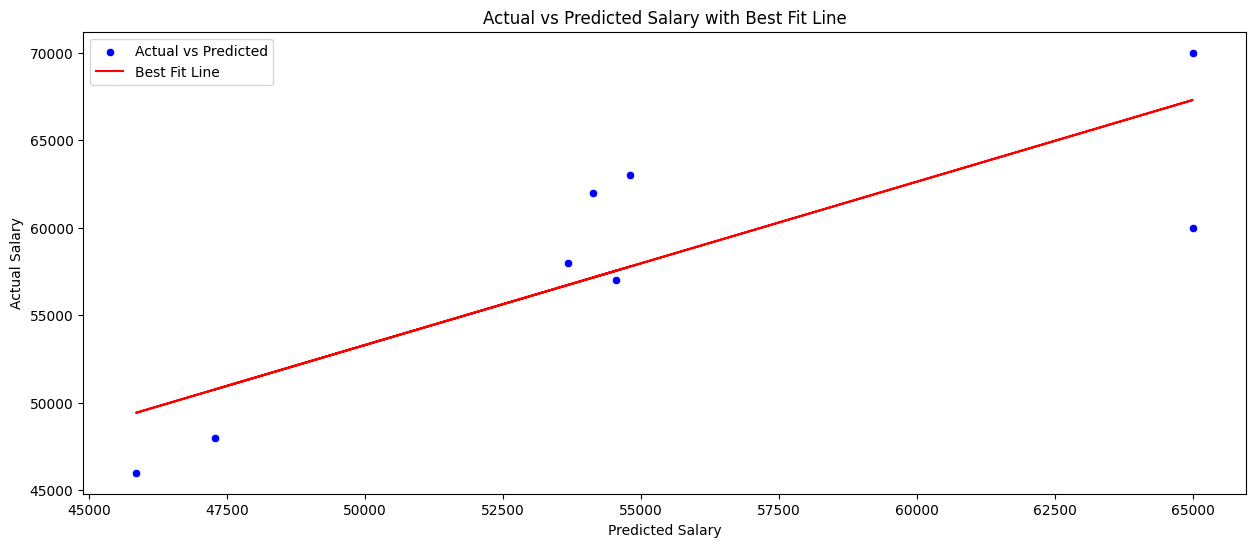

In [39]:
from pyspark.sql.functions import col, mean, sum as F_sum

# Compute statistics needed for regression line (y = mx + b)
n = predictions.count()
x_mean = predictions.agg(mean(col("prediction"))).collect()[0][0]
y_mean = predictions.agg(mean(col("salary"))).collect()[0][0]

# Covariance and variance
cov = predictions.withColumn("cov_term", (col("prediction") - x_mean) * (col("salary") - y_mean)) \
                 .agg(F_sum("cov_term")).collect()[0][0]

var = predictions.withColumn("var_term", (col("prediction") - x_mean)**2) \
                 .agg(F_sum("var_term")).collect()[0][0]

# Regression coefficients
slope = cov / var
intercept = y_mean - slope * x_mean

print(f"Best fit line: salary = {slope:.2f} * prediction + {intercept:.2f}")

# Collect data for plotting
pred_salary = predictions.select("prediction", "salary").collect()
x_vals = [row["prediction"] for row in pred_salary]
y_vals = [row["salary"] for row in pred_salary]

plt.figure(figsize=(15,6))
sns.scatterplot(x=x_vals, y=y_vals, color="blue", label="Actual vs Predicted")
plt.plot(x_vals, [slope*x + intercept for x in x_vals], color="red", label="Best Fit Line")
plt.xlabel("Predicted Salary")
plt.ylabel("Actual Salary")
plt.title("Actual vs Predicted Salary with Best Fit Line")
plt.legend()
plt.show()
